# Carregamento das bibliotecas necessárias para a EDA

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Importação dos dados da análise

In [2]:
path = 'C:\\Users\\breno\\VSCode\\Python\\Testes\\MiranteTeste\\data\\raw\\'

In [3]:
df = pd.read_excel(f'{path}//telco_customer_churn.xlsx')
df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,3325-['N' 'S' 'A' 'U' 'G'],Female,0,Yes,No,61,Yes,No,Fiber optic,No internet service,...,No internet service,No,No,No,Month-to-month,Yes,Mailed check,82.76,5045.65,No
1,3329-['L' 'E' 'Q' 'M' 'H'],Male,0,Yes,No,8,No,No phone service,Fiber optic,No,...,No,Yes,No,No,Month-to-month,Yes,Electronic check,56.44,445.25,Yes
2,6955-['P' 'W' 'Q' 'D' 'X'],Male,0,Yes,No,41,Yes,No,DSL,No,...,No,No,Yes,No,Two year,No,Mailed check,97.57,3995.44,Yes
3,1409-['S' 'L' 'G' 'M' 'D'],Male,1,Yes,No,46,Yes,No,DSL,No,...,No,No,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),110.33,5087.22,No
4,9364-['M' 'J' 'O' 'G' 'Z'],Female,0,Yes,No,33,Yes,No,DSL,No,...,No internet service,No,Yes,No,Two year,Yes,Credit card (automatic),63.35,2101.75,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,2929-['B' 'F' 'Y' 'Z' 'K'],Male,0,Yes,No,16,Yes,No phone service,Fiber optic,No,...,No,No internet service,Yes,Yes,One year,No,Mailed check,28.55,440.23,No
7039,5188-['E' 'E' 'C' 'X' 'D'],Male,0,No,No,38,No,No phone service,Fiber optic,No,...,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),25.23,948.36,No
7040,1953-['Y' 'H' 'T' 'S' 'V'],Male,0,Yes,No,32,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Month-to-month,Yes,Electronic check,34.00,1082.40,No
7041,5387-['D' 'X' 'Y' 'N' 'U'],Female,0,Yes,No,27,Yes,No,DSL,No,...,No,Yes,Yes,Yes,Month-to-month,Yes,Mailed check,114.83,3100.04,No


# Verificando informações sobre o dataset

In [4]:
df.shape

(7043, 21)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [6]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.142411,36.128070,70.022419,2531.331975
std,0.349496,20.888903,28.995621,1902.292990
min,0.000000,0.000000,20.020000,0.000000
25%,0.000000,18.000000,45.080000,1011.235000
50%,0.000000,36.000000,70.310000,2078.220000
75%,0.000000,54.000000,95.250000,3726.085000
max,1.000000,72.000000,119.950000,8623.970000


In [7]:
df.nunique()

customerID          7043
gender                 2
SeniorCitizen          2
Partner                2
Dependents             2
tenure                73
PhoneService           2
MultipleLines          3
InternetService        3
OnlineSecurity         3
OnlineBackup           3
DeviceProtection       3
TechSupport            3
StreamingTV            3
StreamingMovies        3
Contract               3
PaperlessBilling       2
PaymentMethod          4
MonthlyCharges      5060
TotalCharges        6950
Churn                  2
dtype: int64

In [8]:
sumario = pd.DataFrame({
    'Tipo de Dado': df.dtypes,
    'Qtd. Valores Únicos': df.nunique(),
    'Qtd. Valores Nulos': df.isnull().sum(),
    'Percentual de Valores Nulos': (df.isnull().mean())*100
})
sumario

,Tipo de Dado,Qtd. Valores Únicos,Qtd. Valores Nulos,Percentual de Valores Nulos
customerID,object,7043,0,0.0
gender,object,2,0,0.0
SeniorCitizen,int64,2,0,0.0
Partner,object,2,0,0.0
Dependents,object,2,0,0.0
tenure,int64,73,0,0.0
PhoneService,object,2,0,0.0
MultipleLines,object,3,0,0.0
InternetService,object,3,0,0.0
OnlineSecurity,object,3,0,0.0


Não temos valores nulos no nosso dataset, logo podemos seguir com a análise exploratória sem a necessidade de preencher os dados faltantes.

# Proporção de Churn

In [27]:
contagem_churn = df['Churn'].value_counts()
pct_churn = df['Churn'].value_counts(normalize=True)*100

print('Churn')
for categoria in contagem_churn.index:
    print(f'{categoria:<5} {contagem_churn[categoria]} ({pct_churn[categoria]:.2f}%)')

Churn
No    4567 (64.84%)
Yes   2476 (35.16%)


# Primeira visualização de Churn

C:\Users\breno\AppData\Local\Temp\ipykernel_10040\17285902.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df['Churn'], palette=["#0AA31E", "#e01c0d"])


Text(1, 2250, '2476')

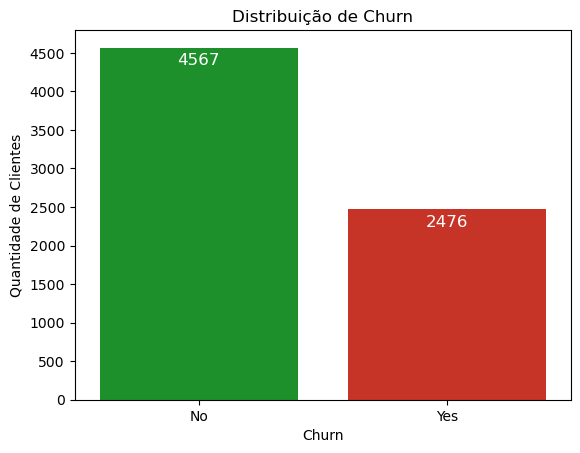

In [15]:
sns.countplot(x=df['Churn'], palette=["#0AA31E", "#e01c0d"])
plt.ylabel("Quantidade de Clientes")
plt.yticks(np.arange(0, 5000, 500))
plt.title("Distribuição de Churn")
plt.text(0, 4350, '4567', fontsize=12, color='white', ha='center')
plt.text(1, 2250, '2476', fontsize=12, color='white', ha='center')

# Comparativo das distribuições das variáveis numéricas

<Axes: xlabel='TotalCharges', ylabel='Count'>

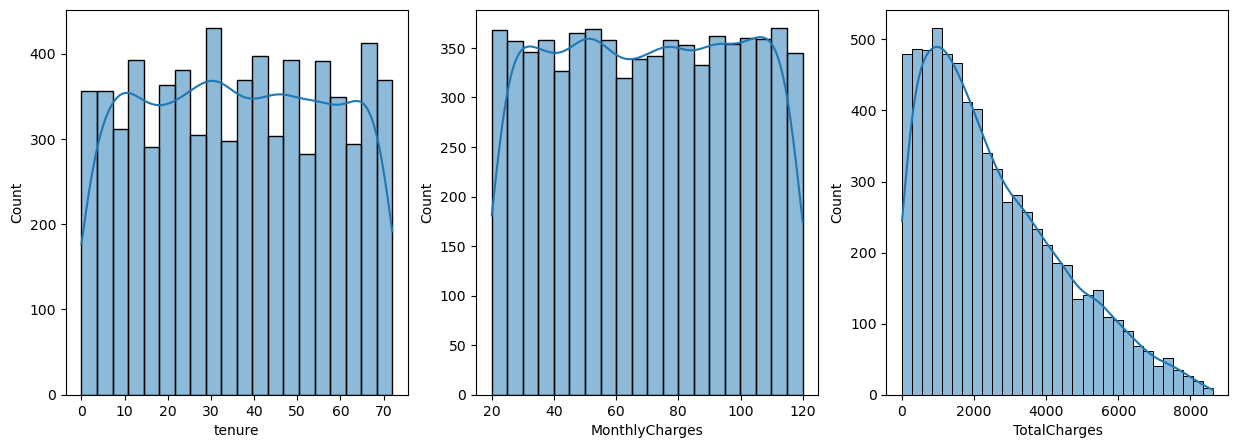

In [20]:
fig,axes = plt.subplots(1,3, figsize=(15,5))

sns.histplot(x=df['tenure'], kde=True, ax=axes[0])
sns.histplot(x=df['MonthlyCharges'], kde=True, ax=axes[1])
sns.histplot(x=df['TotalCharges'], kde=True, ax=axes[2])

# Comparando a distribuição do churn nas variáveis numéricas

## Total de pagamentos

Text(0.5, 1.0, 'Distribuição de Total de Cobranças por Churn')

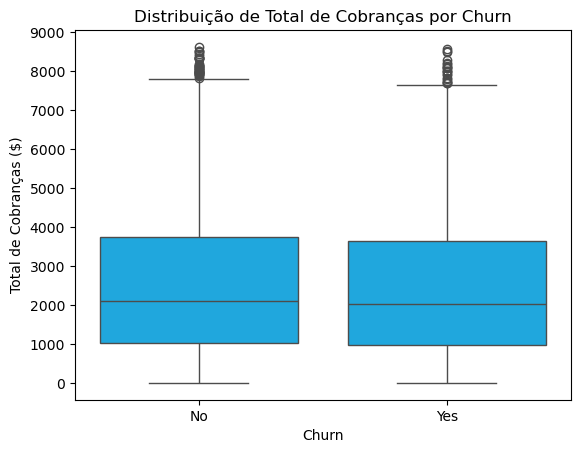

In [21]:
sns.boxplot(x=df['Churn'],y=df['TotalCharges'], color="#00b5fdab")
plt.xlabel("Churn")
plt.ylabel("Total de Cobranças ($)")
plt.yticks(np.arange(0, 10000, 1000))
plt.title("Distribuição de Total de Cobranças por Churn")

## Pagamento mensal

Text(0.5, 1.0, 'Distribuição de Total de Cobranças por Churn')

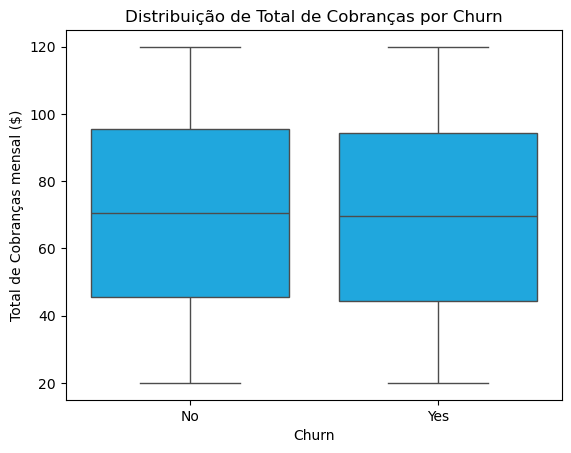

In [22]:
sns.boxplot(x=df['Churn'],y=df['MonthlyCharges'], color="#00b5fdab")
plt.xlabel("Churn")
plt.ylabel("Total de Cobranças mensal ($)")
plt.title("Distribuição de Total de Cobranças por Churn")

## Período como cliente

Text(0.5, 1.0, 'Distribuição do período por Churn')

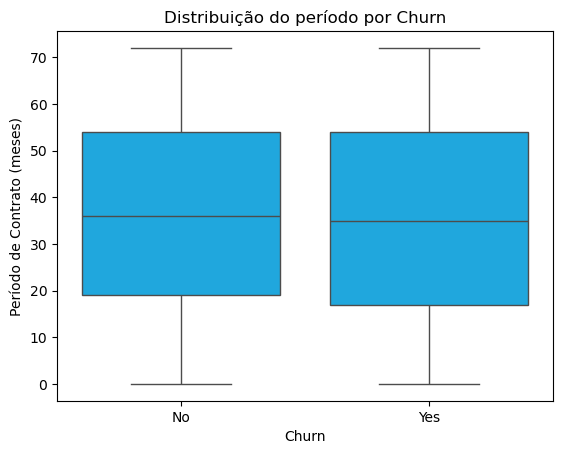

In [23]:
sns.boxplot(x=df['Churn'],y=df['tenure'], color="#00b5fdab")
plt.xlabel("Churn")
plt.ylabel("Período de Contrato (meses)")
plt.title("Distribuição do período por Churn")

# Análise da variável "tenure"

In [24]:
print(df['tenure'].min())
print(df['tenure'].max())

0
72


## Criação de uma nova variável de agrupamentos dos valores presentes na "tenure"

In [25]:
df['tenure_group'] = pd.cut(df['tenure'], bins=[-1, 6, 12, 24, 48, 72], labels=['0-6 meses', '7-12 meses', '13-24 meses', '25-48 meses', '49-72 meses'])
df['tenure_group']

0       49-72 meses
1        7-12 meses
2       25-48 meses
3       25-48 meses
4       25-48 meses
           ...     
7038    13-24 meses
7039    25-48 meses
7040    25-48 meses
7041    25-48 meses
7042    49-72 meses
Name: tenure_group, Length: 7043, dtype: category
Categories (5, object): ['0-6 meses' < '7-12 meses' < '13-24 meses' < '25-48 meses' < '49-72 meses']

## Contagem dos grupos

In [ ]:
contagem_grupos = df['tenure_group'].value_counts()
pct_grupos = df['tenure_group'].value_counts(normalize=True)*100

print('Período agrupado')
for categoria in contagem_grupos.index:
    print(f'{categoria:<11} {contagem_grupos[categoria]} ({pct_grupos[categoria]:.2f}%)')

Período agrupado
25-48 meses 2381 (33.81%)
49-72 meses 2295 (32.59%)
13-24 meses 1130 (16.04%)
0-6 meses   625 (8.87%)
7-12 meses  612 (8.69%)


In [49]:
contagem_tenure = pd.crosstab(
    df["tenure_group"],
    df["Churn"]
)

pct_tenure = pd.crosstab(
    df["tenure_group"],
    df["Churn"],
    normalize="index"
) * 100

tabela_formatada = contagem_tenure.copy()

for coluna in contagem_tenure.columns:
    tabela_formatada[coluna] = [
        f"{count} ({pct:.2f}%)"
        for count, pct in zip(contagem_tenure[coluna], pct_tenure[coluna])
    ]

print(tabela_formatada)

Churn                    No           Yes
tenure_group                             
0-6 meses      408 (65.28%)  217 (34.72%)
7-12 meses     364 (59.48%)  248 (40.52%)
13-24 meses    751 (66.46%)  379 (33.54%)
25-48 meses   1523 (63.96%)  858 (36.04%)
49-72 meses   1521 (66.27%)  774 (33.73%)


Note que durante o período de 7 a 12 meses houve uma maior concentração de churn, é importante avaliar as estratégias de retenção de clientes ao longo do ciclo de consumo.

# Análise das variáveis categóricas comparando o churn

In [55]:
colunas = ['gender', 
'SeniorCitizen',
'Partner', 
'Dependents',
'PhoneService',
'MultipleLines',
'InternetService',
'OnlineSecurity', 
'OnlineBackup',
'DeviceProtection', 
'TechSupport', 
'StreamingTV', 
'StreamingMovies', 
'Contract', 
'PaperlessBilling',
'PaymentMethod'
]

for i in colunas:
    print(f'Variável: {i}')
    print(np.round(pd.crosstab(df[i], df['Churn'], normalize='index')*100, 2))
    print('--------------------------------------------------')

Variável: gender
Churn      No    Yes
gender              
Female  65.33  34.67
Male    64.36  35.64
--------------------------------------------------
Variável: SeniorCitizen
Churn             No    Yes
SeniorCitizen              
0              65.00  35.00
1              63.91  36.09
--------------------------------------------------
Variável: Partner
Churn       No    Yes
Partner              
No       65.10  34.90
Yes      64.59  35.41
--------------------------------------------------
Variável: Dependents
Churn          No    Yes
Dependents              
No          65.17  34.83
Yes         64.07  35.93
--------------------------------------------------
Variável: PhoneService
Churn            No    Yes
PhoneService              
No            64.12  35.88
Yes           64.92  35.08
--------------------------------------------------
Variável: MultipleLines
Churn                No    Yes
MultipleLines                 
No                65.21  34.79
No phone service  64.79  35.21
Ye

Observe que há 2 categorias que são anômalas em duas variáveis distintas.

- Variável "Contract": "Month-to-month"
- Variável "PaymentMethod": "Electronic check"

Pode ser um novo ponto de atenção para a companhia com o objetivo de retenção dos clientes.

# Visualização da discrepância entre essas categorias

## Variável PaymentMethod

Text(0.5, 1.0, 'Percentual de Churn por Método de Pagamento')

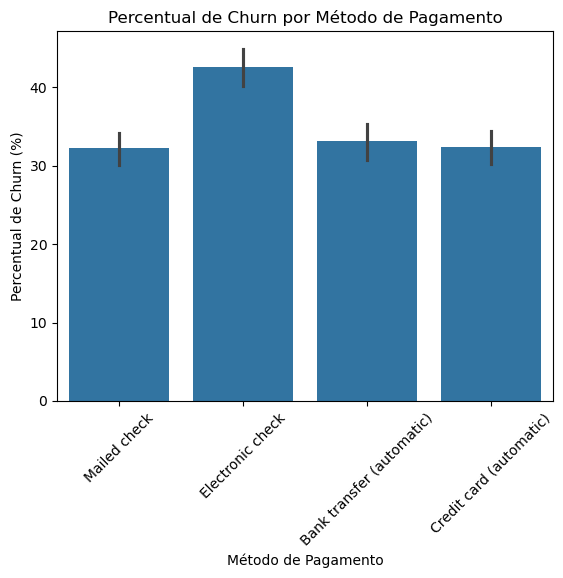

In [56]:
sns.barplot(data=df, x='PaymentMethod', y=100*(df['Churn']=='Yes'))
plt.xticks(rotation=45)
plt.ylabel("Percentual de Churn (%)")
plt.xlabel("Método de Pagamento")
plt.title("Percentual de Churn por Método de Pagamento")

## Variável Contract

Text(0.5, 1.0, 'Percentual de Churn por Tipo de Contrato')

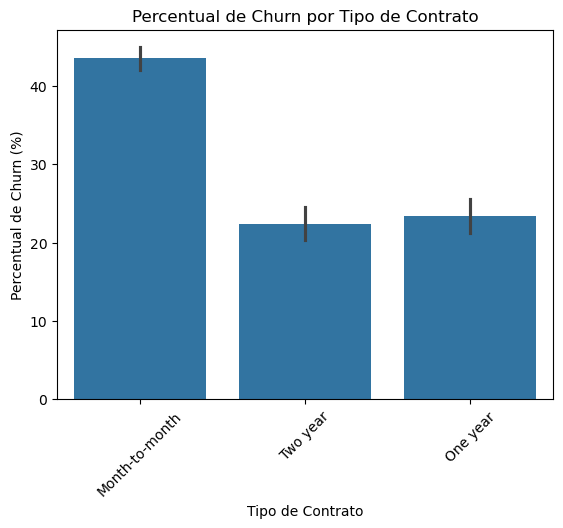

In [57]:
sns.barplot(data=df, x='Contract', y=100*(df['Churn']=='Yes'))
plt.xticks(rotation=45)
plt.ylabel("Percentual de Churn (%)")
plt.xlabel("Tipo de Contrato")
plt.title("Percentual de Churn por Tipo de Contrato")

In [59]:
pd.crosstab(
    [df['Contract'], df['PaymentMethod']],
    df['Churn'],
    normalize='index'
) * 100

Churn                                            No        Yes
Contract       PaymentMethod                                  
Month-to-month Bank transfer (automatic)  60.057748  39.942252
               Credit card (automatic)    58.476190  41.523810
               Electronic check           49.663785  50.336215
               Mailed check               57.746479  42.253521
One year       Bank transfer (automatic)  76.945245  23.054755
               Credit card (automatic)    82.080925  17.919075
               Electronic check           66.489362  33.510638
               Mailed check               81.924198  18.075802
Two year       Bank transfer (automatic)  76.923077  23.076923
               Credit card (automatic)    81.008902  18.991098
               Electronic check           69.761273  30.238727
               Mailed check               83.288410  16.711590

Note que um cliente com contrato mensal e com versão virtual do boleto, possui um churn maior que 50%. Uma possível explicação é que o cliente precisa realizar muitas ações para que o boleto seja pago. 

Por exemplo, se for um boleto enviado via e-mail essa mensagem pode acabar se perdendo no meio de várias newsletter ou inscrições.

Devemos adotar medidas que torne esse processo de acesso ao boleto mais facilitado para os clientes.

Text(0.5, 1.0, 'Distribuição do período de contrato por tipo de contrato e Churn')

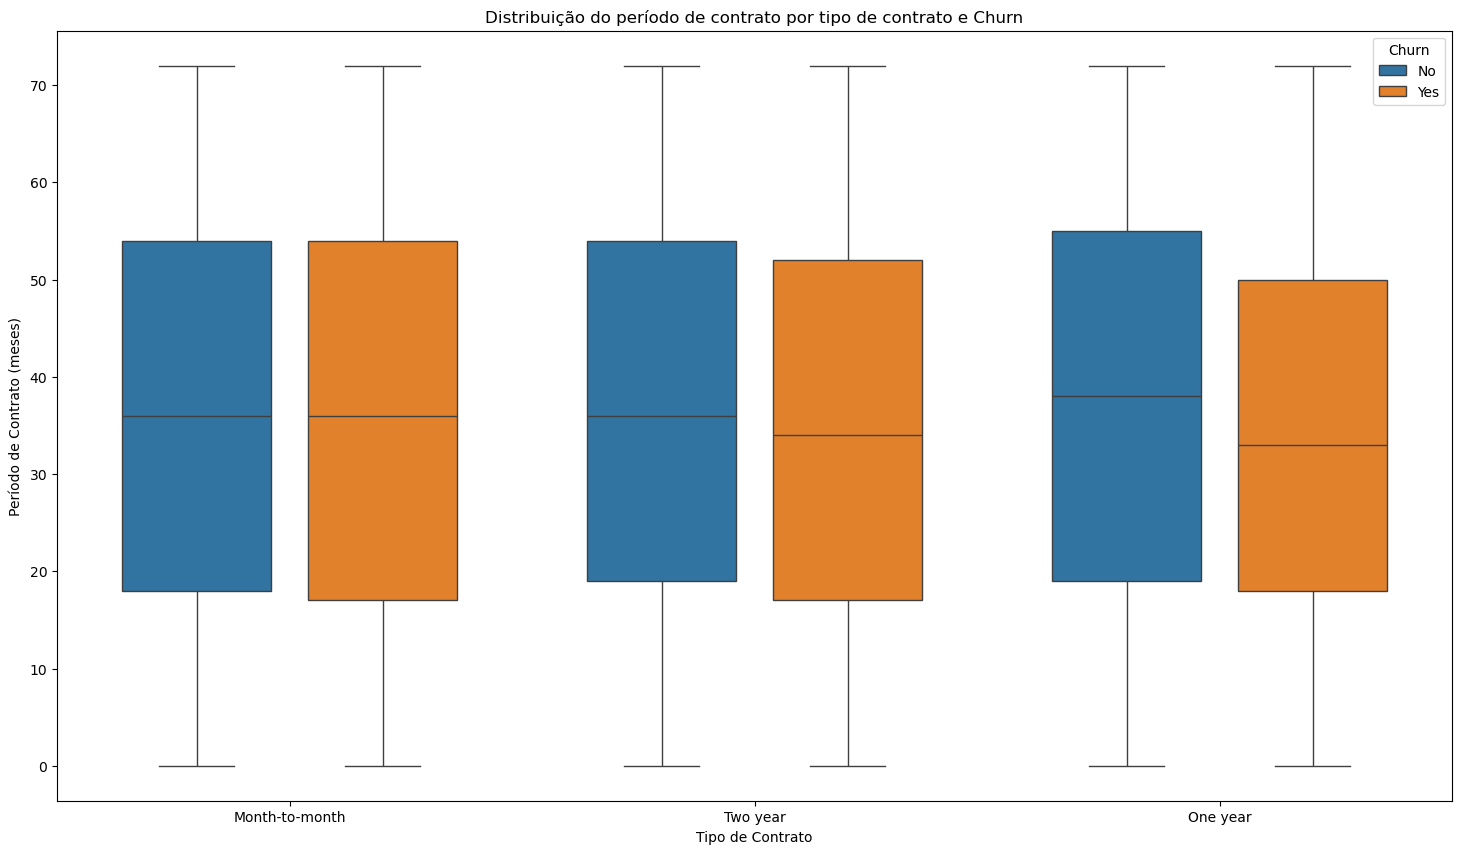

In [60]:
plt.figure(figsize=(18, 10))
sns.boxplot(
    data=df,
    x='Contract',
    y='tenure',
    hue='Churn',
    gap=0.2
)
plt.xlabel("Tipo de Contrato")
plt.ylabel("Período de Contrato (meses)")
plt.title("Distribuição do período de contrato por tipo de contrato e Churn")

Um comparativo da distribuição da variável "tenure" nos tipos de contratos e churn.

O objetivo é visualizar se existe uma grande diferença na distribuição desse período quando separamos o tipo de contrato.

# Correlação entre as variáveis numéricas

<Axes: >

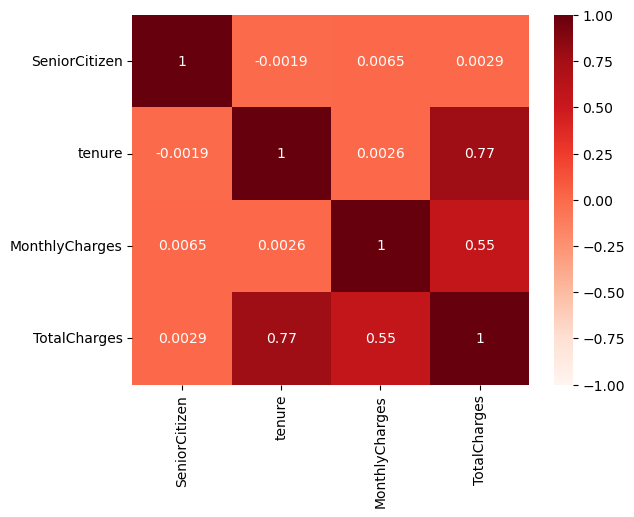

In [63]:
sns.heatmap(df.select_dtypes(include=['float64', 'int64']).corr(), annot=True, cmap='Reds', vmin=-1, vmax=1)

# Comparando a distribuição dos churn nas variáveis numéricas

Variável: tenure


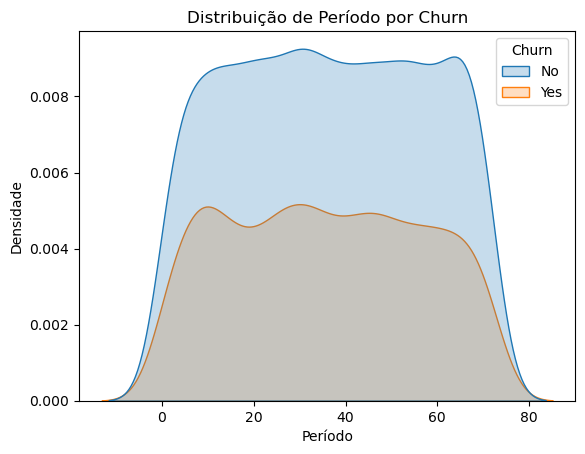

Variável: MonthlyCharges


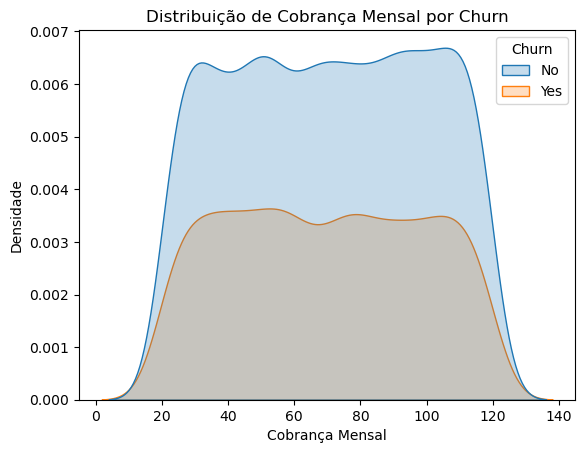

Variável: TotalCharges


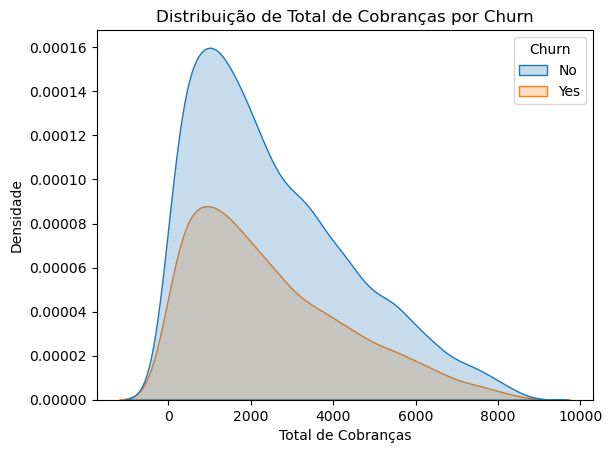

In [64]:
colunas = ['tenure', 'MonthlyCharges', 'TotalCharges']
secundaria = ['Período', 'Cobrança Mensal', 'Total de Cobranças']

for i in colunas:
    print(f'Variável: {i}')
    sns.kdeplot(x=df[i], hue=df['Churn'], fill=True)
    plt.ylabel("Densidade")
    plt.xlabel(secundaria[colunas.index(i)])
    plt.title(f"Distribuição de {secundaria[colunas.index(i)]} por Churn")
    plt.show()

Não há anomalia nas distribuições, nas variáveis numéricas as categorias de churn se comportam de maneira semelhante.